# Plot galaxy pictures with SFH

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py  
from astroquery.svo_fps import SvoFps
from astropy.io import fits
from astropy.visualization import make_lupton_rgb
from reproject import reproject_interp



## 1. Composición de imágenes


### 1.1 Composición de una sola imagen

Primero voy a jugar con componer las imágenes, y ya luego las implemento en los plots de las SFH de FLORAH. Voy a plotear las fotos en la carpeta 'COSMOS_52999'

In [9]:
dir_raw = r'C:\Users\usuario\Documents\TFG\galaxy_pics\cutouts_laura\COSMOS_52999\\'

Procesamos la imagen en cada color por separado

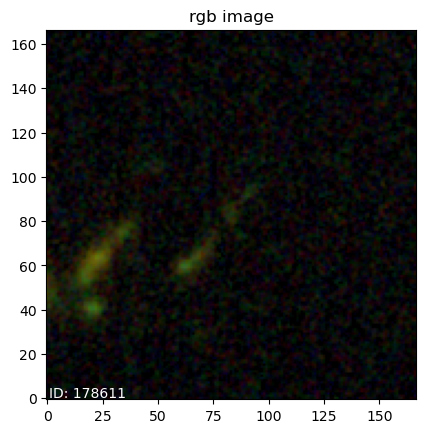

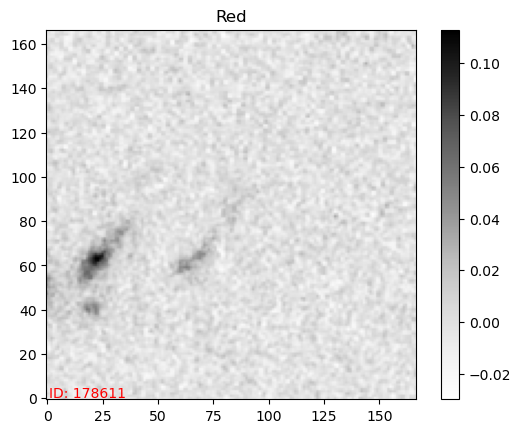

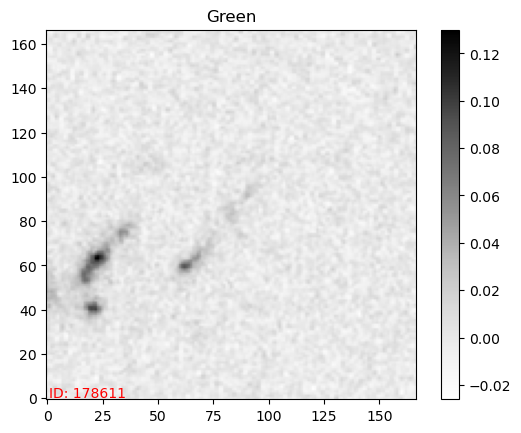

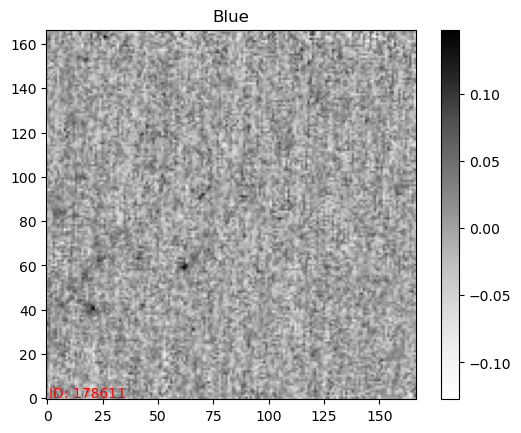

In [10]:
r = fits.open(dir_raw+'F444W_178611.fits')
g = fits.open(dir_raw+'F277W_178611.fits')
b = fits.open(dir_raw+'F115W_178611.fits')
r_data = r[0].data # 0 for primary hdu
g_data = g[0].data
b_data = b[0].data


# make a single image
rgb = make_lupton_rgb(r_data * 2, g_data * 2, b_data * 0.5, 
                        minimum=-0.01,  # Set this slightly below your Mean
                        stretch=0.3,    # A smaller stretch makes faint things brighter
                        Q=8)            # Higher Q increases contrast in the faint areas

# plot rgb image
plt.title('rgb image')
plt.imshow(rgb, origin='lower')
texto = f'ID: 178611'
plt.text(0.5,0.5, texto, color='white')
plt.show()




plt.figure()
plt.imshow(r_data, origin = 'lower', cmap = 'Greys')
texto = f'ID: 178611'
plt.text(0.5,0.5, texto, color='red')
plt.title('Red')
plt.colorbar()
plt.show()



plt.figure()
plt.imshow(g_data, origin = 'lower', cmap = 'Greys')
texto = f'ID: 178611'
plt.text(0.5,0.5, texto, color='red')
plt.title('Green')
plt.colorbar()
plt.show()


plt.figure()
plt.imshow(b_data, origin = 'lower', cmap = 'Greys')
texto = f'ID: 178611'
plt.text(0.5,0.5, texto, color='red')
plt.title('Blue')
plt.colorbar()
plt.show()


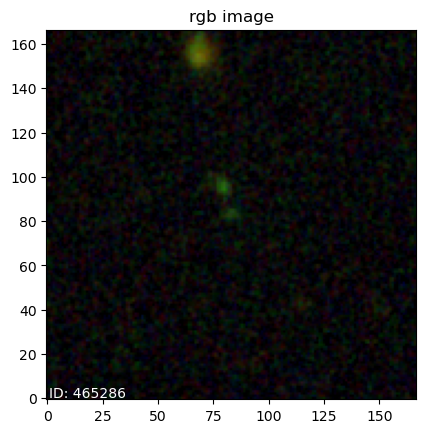

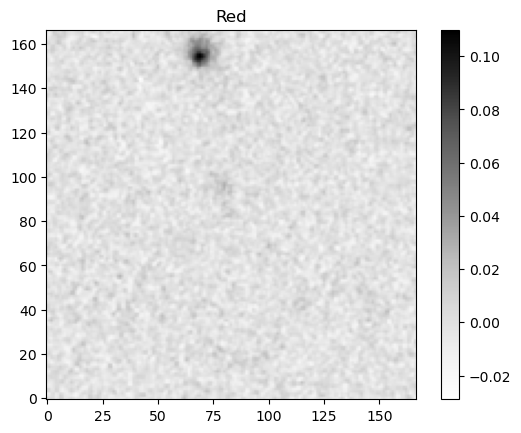

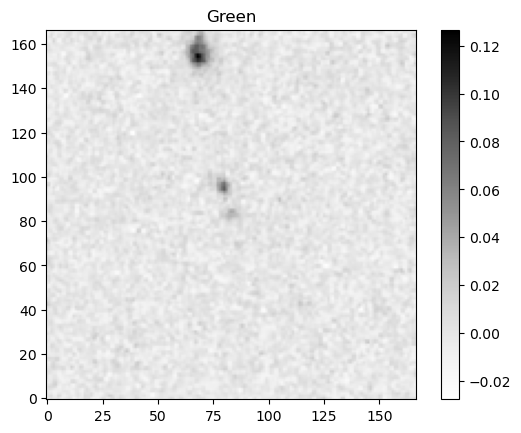

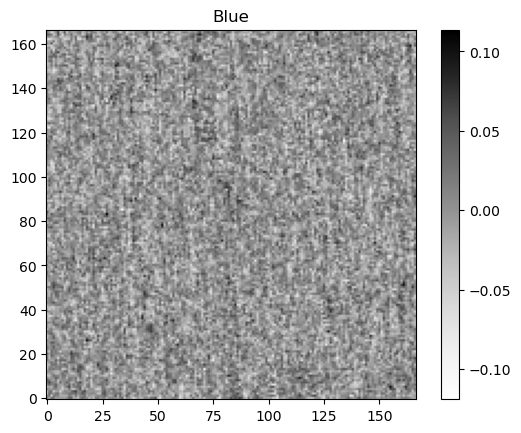

In [11]:
r = fits.open(dir_raw+'F444W_465286.fits')
g = fits.open(dir_raw+'F277W_465286.fits')
b = fits.open(dir_raw+'F115W_465286.fits')
r_data = r[0].data # 0 for primary hdu
g_data = g[0].data
b_data = b[0].data


# make a single image
rgb = make_lupton_rgb(r_data * 2, g_data * 2, b_data * 0.5, 
                        minimum=-0.01,  # Set this slightly below your Mean
                        stretch=0.3,    # A smaller stretch makes faint things brighter
                        Q=8)            # Higher Q increases contrast in the faint areas

# plot rgb image
plt.title('rgb image')
plt.imshow(rgb, origin='lower')
texto = f'ID: 465286'
plt.text(0.5,0.5, texto, color='white')
plt.show()




plt.figure()
plt.imshow(r_data, origin = 'lower', cmap = 'Greys')
plt.title('Red')
plt.colorbar()
plt.show()



plt.figure()
plt.imshow(g_data, origin = 'lower', cmap = 'Greys')
plt.title('Green')
plt.colorbar()
plt.show()


plt.figure()
plt.imshow(b_data, origin = 'lower', cmap = 'Greys')
plt.title('Blue')
plt.colorbar()
plt.show()


Procesamos la imagen en los tres colores

Set OBSGEO-B to     8.881365 from OBSGEO-[XYZ].
Set OBSGEO-H to 1695462140.490 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.885290 from OBSGEO-[XYZ].
Set OBSGEO-H to 1689323928.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.876254 from OBSGEO-[XYZ].
Set OBSGEO-H to 1689778862.210 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


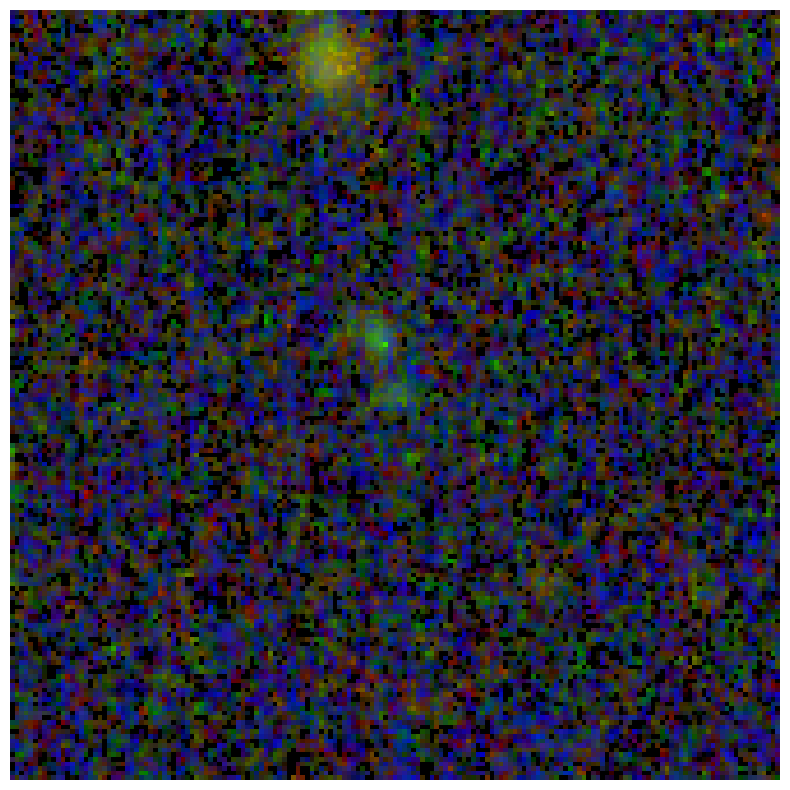

In [12]:
# 1. Load your FITS files (e.g., F444W for Red, F277W for Green, F115W for Blue)
# Note: In infrared, 'longer wavelength = redder'
hdul_r = fits.open(dir_raw+'F444W_465286.fits')
hdul_g = fits.open(dir_raw+'F277W_465286.fits')
hdul_b = fits.open(dir_raw+'F115W_465286.fits') 



# 2. Alignment (Reprojection)
# Filters often have different pixel grids. We align Green and Blue to the Red header.
data_g_aligned, _ = reproject_interp(hdul_g[0], hdul_r[0].header)
data_b_aligned, _ = reproject_interp(hdul_b[0], hdul_r[0].header)
data_r = hdul_r[0].data


# 3. Create the RGB Composite
# make_lupton_rgb applies an 'asinh' stretch, which prevents bright stars
# from saturating while bringing out faint galaxy details.
rgb_image = make_lupton_rgb(data_r, data_g_aligned, data_b_aligned, 
                            minimum=-0.01, stretch=0.05, Q=10)

# 4. Display the result
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, origin='lower')
plt.axis('off')
plt.show()

### 1.2 Composición de toda la historia

Voy a procesar las imágenes de todas las historias para tener una base con la que trabajar. Si hay galaxias que no aparecen, las volveré a procesar más adelante.

Set OBSGEO-B to     8.891407 from OBSGEO-[XYZ].
Set OBSGEO-H to 1695703620.187 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.086902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1268876742.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.979431 from OBSGEO-[XYZ].
Set OBSGEO-H to 1685687438.495 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


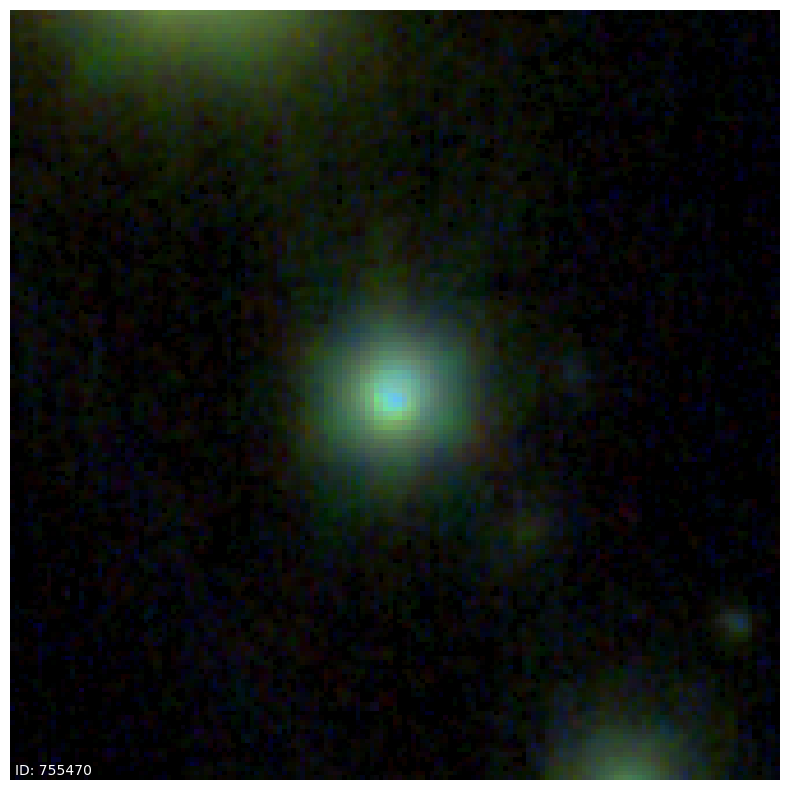

Set OBSGEO-B to     8.881365 from OBSGEO-[XYZ].
Set OBSGEO-H to 1695462140.490 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.930477 from OBSGEO-[XYZ].
Set OBSGEO-H to 1687564443.398 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -10.115093 from OBSGEO-[XYZ].
Set OBSGEO-H to 1378711210.483 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


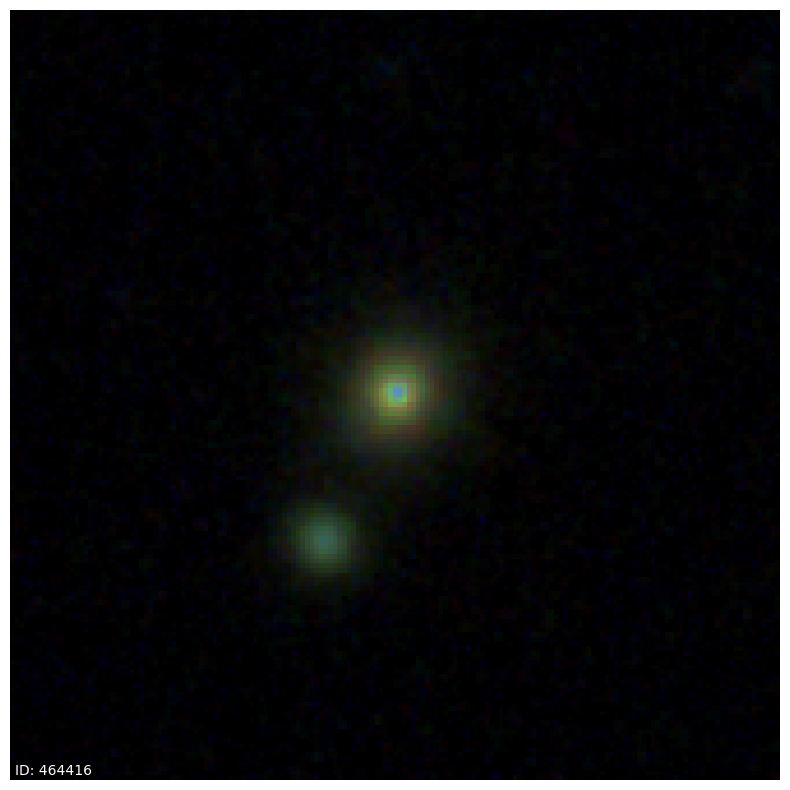

Set OBSGEO-B to     8.877806 from OBSGEO-[XYZ].
Set OBSGEO-H to 1689696703.676 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.878920 from OBSGEO-[XYZ].
Set OBSGEO-H to 1689638854.378 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     4.910965 from OBSGEO-[XYZ].
Set OBSGEO-H to 1248223958.472 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


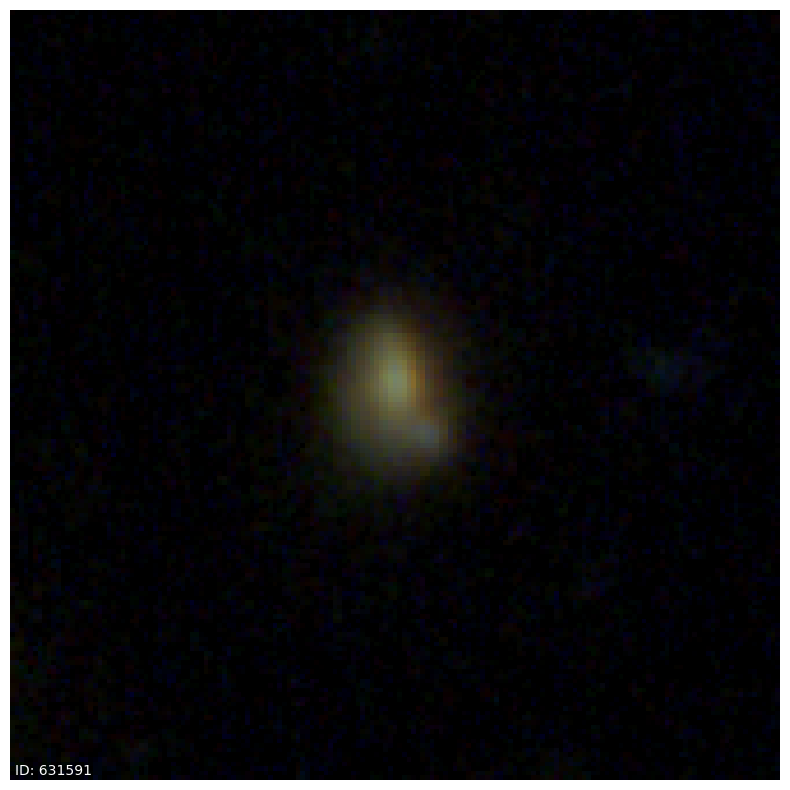

Set OBSGEO-B to     8.881365 from OBSGEO-[XYZ].
Set OBSGEO-H to 1695462140.490 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.885290 from OBSGEO-[XYZ].
Set OBSGEO-H to 1689323928.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.888698 from OBSGEO-[XYZ].
Set OBSGEO-H to 1689165135.984 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


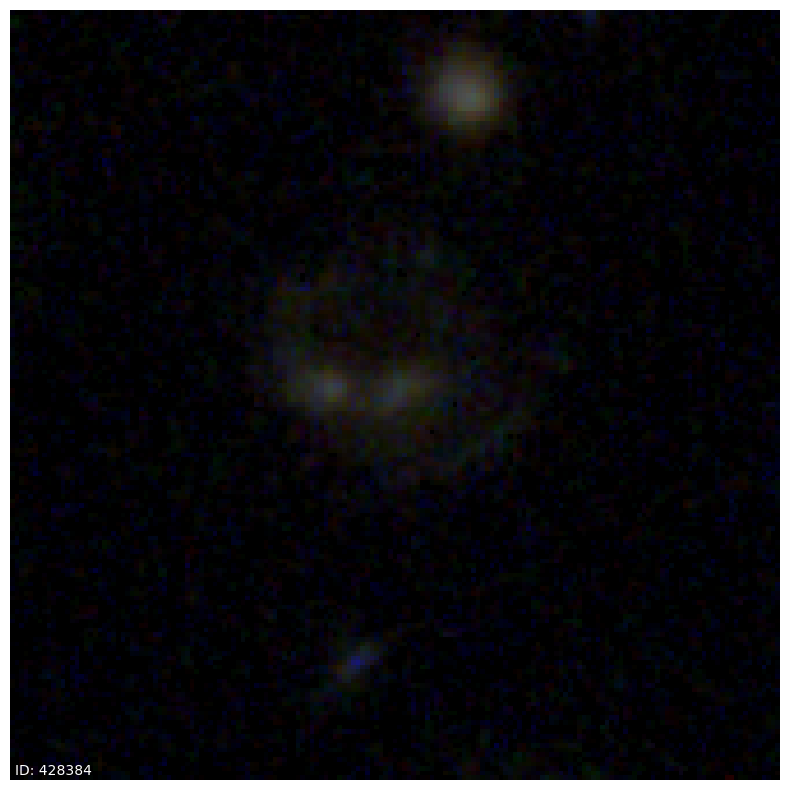

Set OBSGEO-B to    -1.671665 from OBSGEO-[XYZ].
Set OBSGEO-H to 1287298452.158 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.086902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1268876742.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.397977 from OBSGEO-[XYZ].
Set OBSGEO-H to 1266993810.076 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


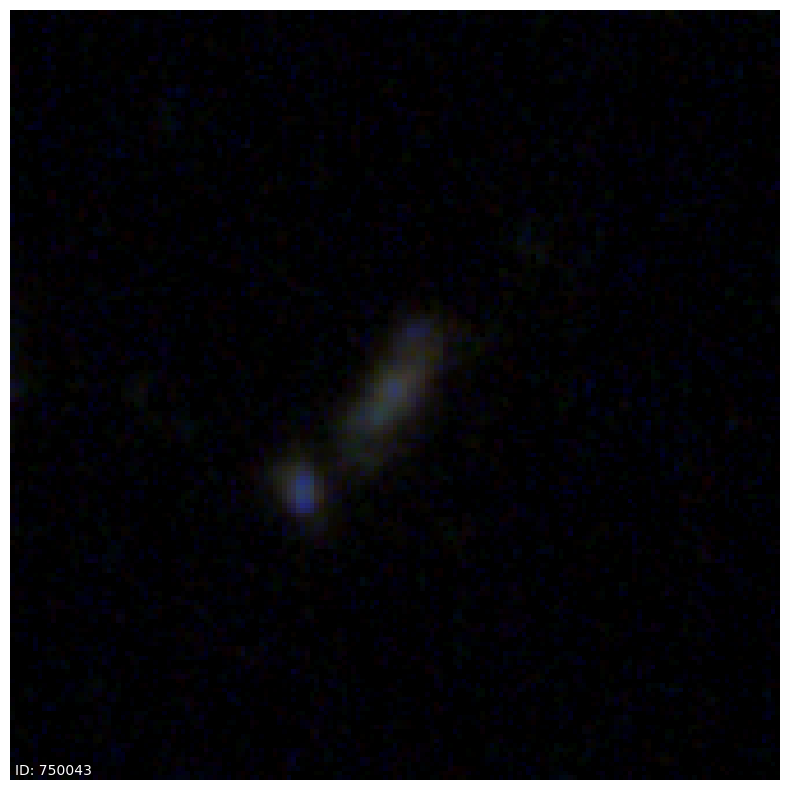

Set OBSGEO-B to     8.949883 from OBSGEO-[XYZ].
Set OBSGEO-H to 1696433383.567 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -10.478127 from OBSGEO-[XYZ].
Set OBSGEO-H to 1373213329.829 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     4.737340 from OBSGEO-[XYZ].
Set OBSGEO-H to 1249045326.390 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


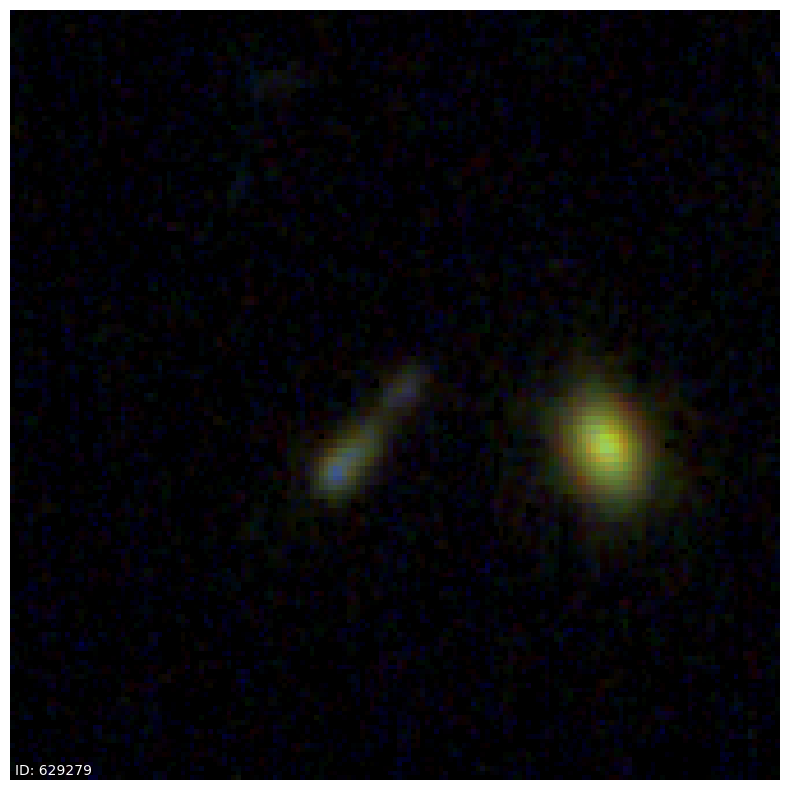

Set OBSGEO-B to     8.888427 from OBSGEO-[XYZ].
Set OBSGEO-H to 1695637594.588 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    -1.127172 from OBSGEO-[XYZ].
Set OBSGEO-H to 1278402912.255 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.968752 from OBSGEO-[XYZ].
Set OBSGEO-H to 1685971461.835 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


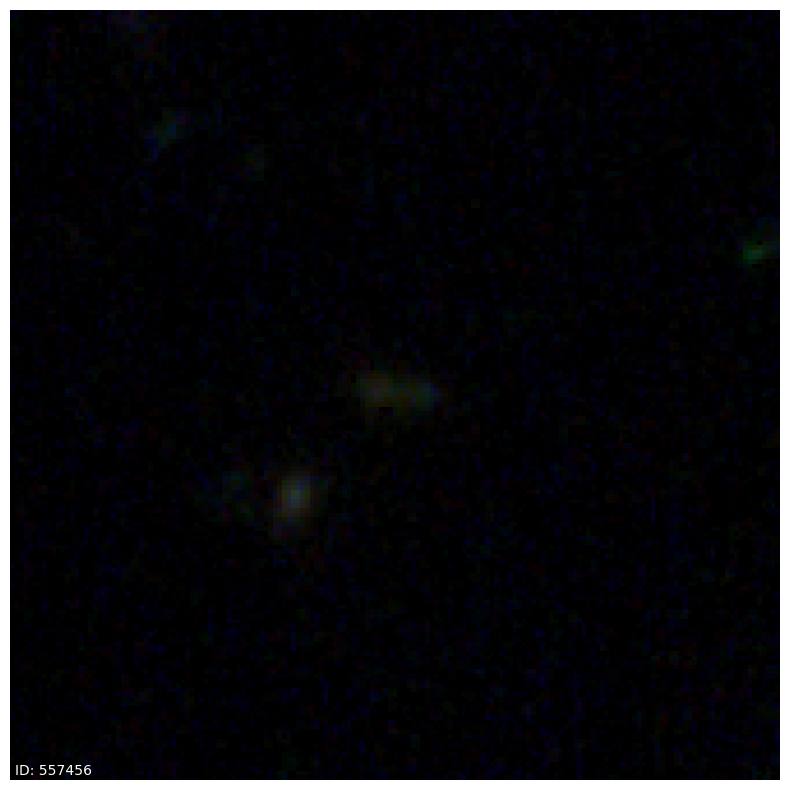

Set OBSGEO-B to     0.487383 from OBSGEO-[XYZ].
Set OBSGEO-H to 1272611989.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     0.449787 from OBSGEO-[XYZ].
Set OBSGEO-H to 1272850973.485 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.861146 from OBSGEO-[XYZ].
Set OBSGEO-H to 1264258652.042 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


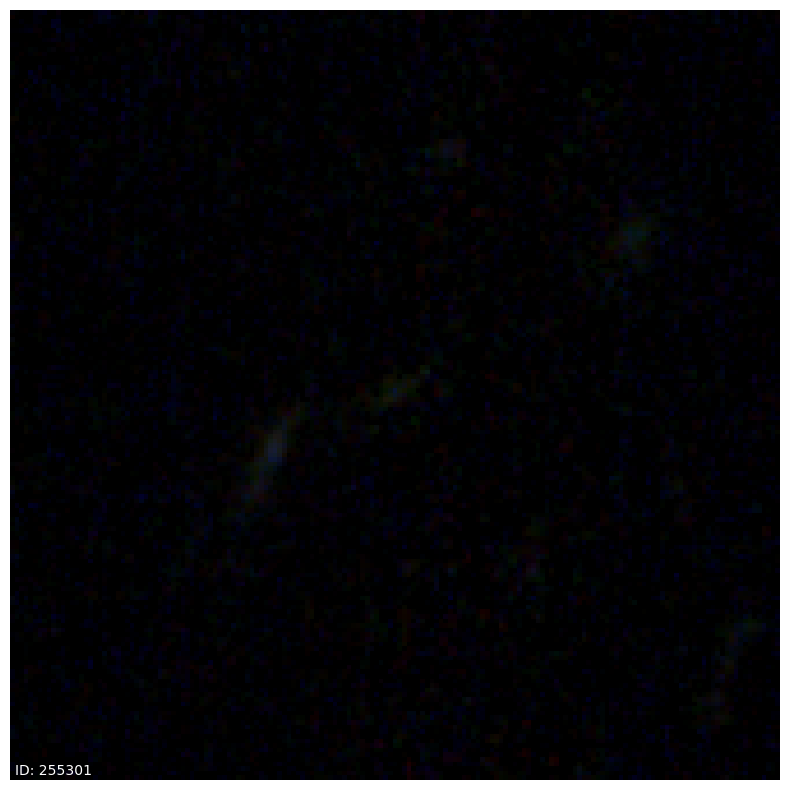

In [13]:
# Sacamos galaxy_ids
selected_root = 755470
file_path = rf"C:\Users\usuario\Documents\TFG\galaxy_pics\galaxias_select\COSMOS_{selected_root}.csv"
output_dir = rf'C:\Users\usuario\Documents\TFG\galaxy_pics\composed_pics\COSMOS_{selected_root}\\'
galaxy_df = pd.read_csv(file_path)
galaxy_ids = galaxy_df['id']


dir_raw = rf'C:\Users\usuario\Documents\TFG\galaxy_pics\cutouts_laura\COSMOS_{int(galaxy_ids[0])}\\'

for obj_id in galaxy_ids:
    obj_id = int(obj_id)
    # 1. Load your FITS files (e.g., F444W for Red, F277W for Green, F115W for Blue)
    # Note: In infrared, 'longer wavelength = redder'
    hdul_r = fits.open(dir_raw+f'F444W_{obj_id}.fits')
    hdul_g = fits.open(dir_raw+f'F277W_{obj_id}.fits')
    hdul_b = fits.open(dir_raw+f'F150W_{obj_id}.fits') 


    # 2. Alignment (Reprojection)
    # Filters often have different pixel grids. We align Green and Blue to the Red header.
    data_g_aligned, _ = reproject_interp(hdul_g[0], hdul_r[0].header)
    data_b_aligned, _ = reproject_interp(hdul_b[0], hdul_r[0].header)
    data_r = hdul_r[0].data
    data_g = hdul_g[0].data
    data_b = hdul_b[0].data


    # 3. Create the RGB Composite
    # make_lupton_rgb applies an 'asinh' stretch, which prevents bright stars
    # from saturating while bringing out faint galaxy details.
    rgb_image = make_lupton_rgb(data_r, data_g, data_b, 
                                minimum=-0.001, stretch=0.5, Q=10)

    output_file = f'ID_{obj_id}.jpg'
    output_pic = os.path.join(output_dir, output_file)
    

    # 4. Display the result
    plt.figure(figsize=(10,10))
    texto = f'ID: {obj_id}'
    plt.text(0.5,0.5, texto, color='white')
    plt.imshow(rgb_image, origin='lower')
    plt.axis('off')
    plt.savefig(output_pic, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()